In [1]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")

In [3]:
# model = ChatOpenAI()

In [5]:
class ChatState(MessagesState):
    summary: str

In [6]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = llm.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(f"Current number of messages: {len(messages)}")

    response = llm.invoke(messages)
    return {"messages": [response]}

In [8]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [10]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

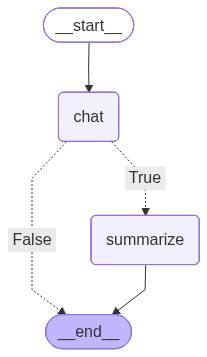

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics in just few lines')
show_state()

Current number of messages: 1

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics in just few lines
- AIMessage : **Quantum physics in a nutshell**

- **Quantization:** Energy, momentum, and oth


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

Current number of messages: 3

--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Quantum Physics in just few lines
- AIMessage : **Quantum physics in a nutshell**

- **Quantization:** Energy, momentum, and oth
- HumanMessage : How is Albert Einstien related?
- AIMessage : ### Albert Einstein’s Connection to Quantum Physics  

| Area | What Einstein Di


In [16]:
run_turn('What are some of Einstien"s famous work. List 3 of them')
show_state()

Current number of messages: 5

--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics in just few lines
- AIMessage : **Quantum physics in a nutshell**

- **Quantization:** Energy, momentum, and oth
- HumanMessage : How is Albert Einstien related?
- AIMessage : ### Albert Einstein’s Connection to Quantum Physics  

| Area | What Einstein Di
- HumanMessage : What are some of Einstien"s famous work. List 3 of them
- AIMessage : **Three of Albert Einstein’s most famous contributions**

| # | Work (year) | Wh


In [17]:
run_turn('Explain special theory of relativity in brief')
show_state()

Current number of messages: 7

--- STATE ---
summary: **Conversation Summary**

| Turn | Speaker | Content |
|------|---------|---------|
| 1 | **User** | Requested “Quantum Physics in just few lines.” |
| 2 | **Assistant** | Provided a concise 5‑point overview of quantum physics (quantization, wave‑particle duality, superposition, entanglement, uncertainty principle). |
| 3 | **User** | Asked “How is Albert Einstein related?” |
| 4 | **Assistant** | Explained Einstein’s key connections to quantum theory: photo‑electric effect, Bose‑Einstein statistics, EPR paradox, his critiques, and how relativity feeds into quantum field theory. |
| 5 | **User** | Requested “What are some of Einstein’s famous work. List 3 of them.” |
| 6 | **Assistant** | Listed three landmark works (Special Relativity, Photo‑electric effect, General Relativity) with brief descriptions and significance. |
| 7 | **User** | Asked for a brief explanation of the Special Theory of Relativity. |
| 8 | **Assistant** | Gave

In [18]:
run_turn('My name is Sushant.')
show_state()

Current number of messages: 3

--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Explain special theory of relativity in brief
- AIMessage : **Special Theory of Relativity (1905) – a concise overview**

---

### 1. The tw
- HumanMessage : My name is Sushant.
- AIMessage : Nice to meet you, Sushant! How can I help you today?
